In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('semiconductor_yield_forecasting_data.csv')

In [8]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

model_features = ['critical_dimension','vth','oxide_thickness','thickness_uniformity','defect_density','deposition_rate','etch_rate']

x= df[model_features].dropna()

vif_data = pd.DataFrame()
vif_data['feature'] = x.columns
vif_data['VIF'] = [
    variance_inflation_factor(x.values,i)
    for i in range (x.shape[1])
]

vif_data.sort_values('VIF', ascending=False)

,feature,VIF
4,defect_density,65312.394757
3,thickness_uniformity,51923.692639
6,etch_rate,965.866806
2,oxide_thickness,298.277211
5,deposition_rate,223.931886
1,vth,153.403655
0,critical_dimension,96.948232


In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

model_features = ['critical_dimension','vth','oxide_thickness']

x= df[model_features].dropna()

vif_data = pd.DataFrame()
vif_data['feature'] = x.columns
vif_data['VIF'] = [
    variance_inflation_factor(x.values,i)
    for i in range (x.shape[1])
]

vif_data.sort_values('VIF', ascending=False)

,feature,VIF
2,oxide_thickness,121.602182
1,vth,105.844598
0,critical_dimension,70.983942


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [11]:
def evaluate_model(x,y,model,model_name):
    x_train, x_test, y_train, y_test = train_test_split(
        x,y, test_size = 0.2, random_state = 42
    )

    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    return{
        'Model': model_name,
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred)
    }

y = df['yield']

key_features = [
    'critical_dimension',
    'vth',
    'oxide_thickness'
]

full_features = [
    "critical_dimension",
    "vth",
    "oxide_thickness",
    "etch_rate",
    "deposition_rate",
    "pressure",
    "temperature",
    "exposure_time",
    "focus_offset",
    "dose",
    "implant_energy",
    "tilt_angle",
    "resistivity",
    "leakage_current",
    "resistance"
]

results = []

results.append(
    evaluate_model(
        df[key_features],
        y,
        LinearRegression(),
        'Linear Regression - Key Parameters'
    )
)
results.append(
    evaluate_model(
        df[full_features],
        y,
        LinearRegression(),
        'Linear Regression - Full Parameters'
    )
)
results.append(
    evaluate_model(
        df[key_features],
        y,
        RandomForestRegressor(n_estimators=200, random_state=42),
        'Random Forest - Key Parameters'
    )
)
results.append(
    evaluate_model(
        df[full_features],
        y,
        RandomForestRegressor(n_estimators=200, random_state=42),
        'Random Forest - Full Parameters'
    )
)

model_results = pd.DataFrame(results)
model_results        

,Model,MAE,RMSE,R2
0,Linear Regression - Key Parameters,0.100903,0.128377,0.472506
1,Linear Regression - Full Parameters,0.103947,0.132665,0.436676
2,Random Forest - Key Parameters,0.091294,0.112668,0.593702
3,Random Forest - Full Parameters,0.091534,0.110228,0.611106


From random forest model suggest key parameters capture most of the predictive signal 

In [12]:
# run feature importance
rf_full = RandomForestRegressor(
    n_estimators = 200,
    random_state = 42
)

rf_full.fit(df[full_features], df['yield'])

feature_importance = pd.DataFrame({
    'feature' : full_features,
    'importance' : rf_full.feature_importances_
}).sort_values('importance',ascending=False)

feature_importance

,feature,importance
0,critical_dimension,0.578824
1,vth,0.103974
2,oxide_thickness,0.041024
9,dose,0.027319
13,leakage_current,0.025438
5,pressure,0.024750
3,etch_rate,0.024494
11,tilt_angle,0.023782
4,deposition_rate,0.022695
6,temperature,0.022141


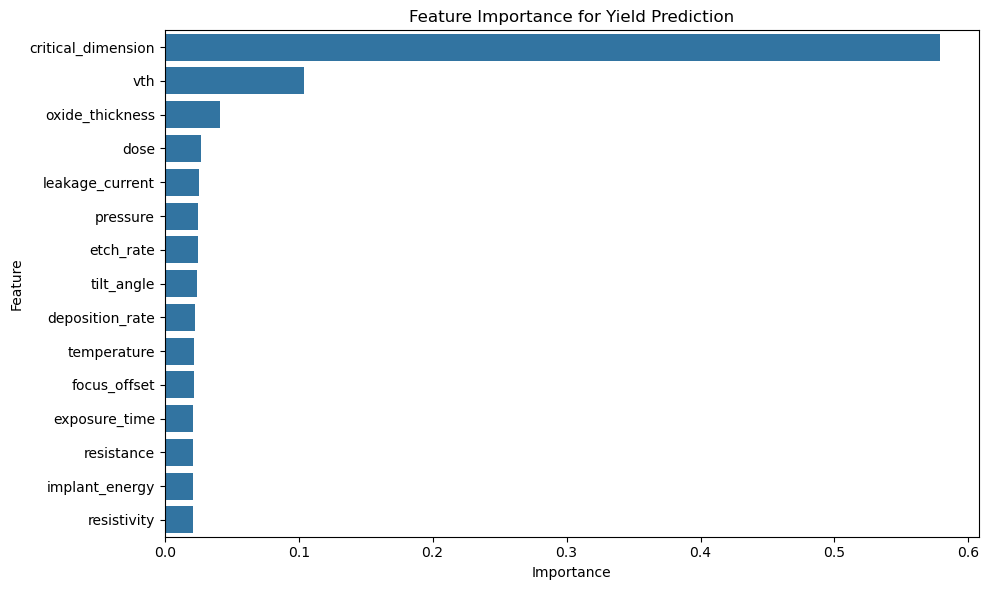

In [13]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance,
    x='importance',
    y="feature"
)

plt.title("Feature Importance for Yield Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Feature Importance Interpretation

The Random Forest feature importance result shows that `critical_dimension` is the dominant predictor of wafer yield, followed by `vth` and `oxide_thickness`.

This result is consistent with the earlier correlation and yield-group boxplot analysis. Low-yield wafers showed higher values in these three parameters, and the model also relied most heavily on them when estimating yield.

Other process parameters such as `etch rate`, `deposition rate`, `temperature`, `pressure`, `exposure time`, and `implant-related parameters` contributed relatively less to the model. This suggests that their overall predictive value is weaker in this dataset, although their impact may still be process-specific or indirect.

Because some features are correlated, the feature importance ranking should be interpreted as model-based evidence rather than direct causal proof.